<p style="margin: 5px 0 0 0; color: #666;"><em>Desarrollado con Claude - Anthropic</em></p>

# 16. Fundamentos de Modelado Predictivo

Ruta de Analista de Datos Basico con Python

---

Este notebook conecta el EDA con los proyectos aplicados.

Objetivo: aprender el flujo minimo de modelado predictivo para resolver problemas reales de negocio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

sns.set_theme(style='whitegrid')
np.random.seed(42)
pd.set_option('display.max_columns', None)

print('Notebook 16 listo: Fundamentos de Modelado Predictivo')

Notebook 16 listo: Fundamentos de Modelado Predictivo


## Introduccion al Modelado Predictivo

### Que es?
El modelado predictivo es una metodologia para estimar resultados futuros usando patrones aprendidos desde datos historicos.

No es "adivinar": es construir una funcion que relacione variables de entrada (features) con una salida esperada (target), y medir que tan bien generaliza en datos no vistos.

### Para que sirve?
Te permite anticiparte a escenarios de negocio:
- detectar clientes con alto riesgo de abandono
- estimar demanda o ventas futuras
- priorizar casos para equipos comerciales u operativos
- asignar recursos con mejor criterio

En la practica, reduce decisiones basadas solo en intuicion.

### Como se usa?
El flujo minimo profesional que aprenderas aqui es:
1. Definir problema de negocio y objetivo analitico
2. Preparar dataset y separar target/features
3. Dividir train/validation/test
4. Construir baseline para comparar
5. Entrenar primer modelo supervisado
6. Evaluar y documentar hallazgos/limitaciones

## 1. Definicion del Problema

### Que es?
Es convertir una necesidad del negocio en una pregunta analitica clara, medible y accionable.

Ejemplo:
- Necesidad de negocio: reducir perdida de clientes
- Pregunta analitica: que clientes tienen mayor probabilidad de abandonar en los proximos meses?

### Para que sirve?
Define:
- que variable vas a predecir
- con que horizonte temporal
- para que decision se usara el resultado

Sin esta definicion, puedes construir un modelo tecnicamente correcto pero inutil para negocio.

### Como se usa?
Caso didactico de este notebook:
- Industria: fintech
- Objetivo: anticipar churn
- Stakeholder: equipo de retencion
- Accion esperada: priorizar clientes para campañas preventivas

In [2]:
# ------------------------------------------------------
# Generacion de dataset sintetico para caso de churn
# ------------------------------------------------------
# Este bloque crea datos "realistas" para practicar el flujo
# completo de modelado sin depender de archivos externos.
n = 4000

df = pd.DataFrame({
    'antiguedad_meses': np.random.randint(1, 61, size=n),
    'uso_mensual_horas': np.random.gamma(shape=2.0, scale=8.0, size=n),
    'tickets_soporte': np.random.poisson(lam=1.8, size=n),
    'monto_mensual': np.random.normal(45, 12, size=n).clip(12, 120),
    'metodo_pago': np.random.choice(['tarjeta', 'transferencia', 'efectivo'], size=n, p=[0.65, 0.25, 0.10]),
    'plan': np.random.choice(['basico', 'plus', 'premium'], size=n, p=[0.55, 0.30, 0.15]),
    'region': np.random.choice(['norte', 'centro', 'sur'], size=n, p=[0.35, 0.45, 0.20])
})

# Construimos una probabilidad de churn con una funcion logistica.
# La idea es simular relaciones plausibles:
# - mas tickets => mayor riesgo
# - mayor antiguedad/uso => menor riesgo
# - ciertos planes/metodos => diferencias de riesgo
logit = (
    -1.8
    + 0.45 * (df['tickets_soporte'] >= 3).astype(int)
    - 0.02 * df['antiguedad_meses']
    - 0.03 * df['uso_mensual_horas']
    + 0.015 * df['monto_mensual']
    + 0.25 * (df['metodo_pago'] == 'efectivo').astype(int)
    + 0.20 * (df['plan'] == 'basico').astype(int)
    + np.random.normal(0, 0.5, size=n)
)

proba = 1 / (1 + np.exp(-logit))
df['abandono'] = np.random.binomial(1, proba)

print('Dimension:', df.shape)
print('Tasa de abandono: {:.2%}'.format(df['abandono'].mean()))
df.head()

Dimension: (4000, 8)
Tasa de abandono: 14.42%


,antiguedad_meses,uso_mensual_horas,tickets_soporte,monto_mensual,metodo_pago,plan,region,abandono
0,39,8.620692,0,67.641717,tarjeta,basico,centro,0
1,52,4.107727,1,32.253638,tarjeta,premium,norte,1
2,29,18.979798,1,66.571365,tarjeta,plus,centro,0
3,15,11.046765,1,43.123756,tarjeta,premium,centro,0
4,43,3.783460,1,42.968895,tarjeta,plus,norte,0


## 2. Variable Objetivo y Features

### Que es?
- Variable objetivo (y): resultado a predecir (en este caso, abandono)
- Features (X): variables que ayudan a explicar/predicir ese resultado

### Para que sirve?
Esta separacion es esencial porque evita confusiones metodologicas.

Si mezclas objetivo y features, o incluyes columnas incorrectas, puedes introducir sesgos o fugas de informacion.

### Como se usa?
1. Definir explicitamente el target
2. Separar X e y
3. Revisar tipos de datos (numericos y categoricos)
4. Preparar preprocesamiento acorde a cada tipo de feature

In [3]:
target = 'abandono'
X = df.drop(columns=[target])
y = df[target]

numericas = X.select_dtypes(include=['number']).columns.tolist()
categoricas = X.select_dtypes(exclude=['number']).columns.tolist()

print('Target:', target)
print('Features numericas:', numericas)
print('Features categoricas:', categoricas)

Target: abandono
Features numericas: ['antiguedad_meses', 'uso_mensual_horas', 'tickets_soporte', 'monto_mensual']
Features categoricas: ['metodo_pago', 'plan', 'region']


## 3. Separacion Train, Validation y Test

### Que es?
Es una estrategia para evaluar modelos de manera honesta.

- Train: donde el modelo aprende
- Validation: donde ajustamos decisiones (ej. hiperparametros)
- Test: evaluacion final, una sola vez

### Para que sirve?
Evita sobreajuste y expectativas irreales.

Si evaluas con los mismos datos de entrenamiento, el resultado suele verse mejor de lo que realmente sera en produccion.

### Como se usa?
En este notebook usamos 70/15/15 y stratify para preservar la proporcion de clases.
Esto hace la comparacion mas estable y realista.

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)
print('Tasa churn train: {:.2%}'.format(y_train.mean()))
print('Tasa churn val:   {:.2%}'.format(y_val.mean()))
print('Tasa churn test:  {:.2%}'.format(y_test.mean()))

Train: (2800, 7) Validation: (600, 7) Test: (600, 7)
Tasa churn train: 14.43%
Tasa churn val:   14.50%
Tasa churn test:  14.33%


## 4. Baseline del Modelo

### Que es?
Un baseline es la referencia minima contra la que se comparan modelos mas elaborados.

En clasificacion, una opcion comun es predecir siempre la clase mayoritaria.

### Para que sirve?
Sirve para responder una pregunta critica:
"Mi modelo realmente aprende algo util o solo parece complejo?"

Si no superas baseline, no hay evidencia de valor adicional.

### Como se usa?
Aplicamos DummyClassifier y medimos sus metricas en validacion.
Luego comparamos contra el modelo supervisado que construiremos despues.

In [5]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train[numericas], y_train)
pred_base = baseline.predict(X_val[numericas])

acc_base = accuracy_score(y_val, pred_base)
f1_base = f1_score(y_val, pred_base, zero_division=0)

print('Baseline accuracy: {:.3f}'.format(acc_base))
print('Baseline F1: {:.3f}'.format(f1_base))

Baseline accuracy: 0.855
Baseline F1: 0.000


## 5. Primer Modelo Supervisado

### Que es?
Entrenaremos una Regresion Logistica con preprocesamiento integrado en pipeline.

### Para que sirve?
Es un excelente primer modelo porque:
- funciona bien en clasificacion binaria
- es rapido de entrenar
- permite trazabilidad del flujo de datos
- suele ser un baseline fuerte frente a modelos mas complejos

### Como se usa?
1. Escalar variables numericas
2. Codificar categoricas con one-hot
3. Entrenar modelo sobre train
4. Evaluar en validation con metricas clave (accuracy, precision, recall, F1, ROC AUC)

Importante: en churn, recall suele ser especialmente relevante porque perder un cliente no detectado puede ser costoso.

In [6]:
# ------------------------------------------------------
# Pipeline de modelado: preprocesamiento + clasificador
# ------------------------------------------------------
preproceso = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas)
    ]
)

modelo = Pipeline(steps=[
    ('preproceso', preproceso),
    ('clf', LogisticRegression(max_iter=1000))
])

# Entrenamos en train
modelo.fit(X_train, y_train)

# Evaluamos en validation para decidir ajustes antes de test
pred_val = modelo.predict(X_val)
proba_val = modelo.predict_proba(X_val)[:, 1]

metricas = {
    'accuracy': accuracy_score(y_val, pred_val),
    'precision': precision_score(y_val, pred_val, zero_division=0),
    'recall': recall_score(y_val, pred_val, zero_division=0),
    'f1': f1_score(y_val, pred_val, zero_division=0),
    'roc_auc': roc_auc_score(y_val, proba_val)
}

pd.Series(metricas).round(3)

accuracy     0.855
precision    0.000
recall       0.000
f1           0.000
roc_auc      0.711
dtype: float64

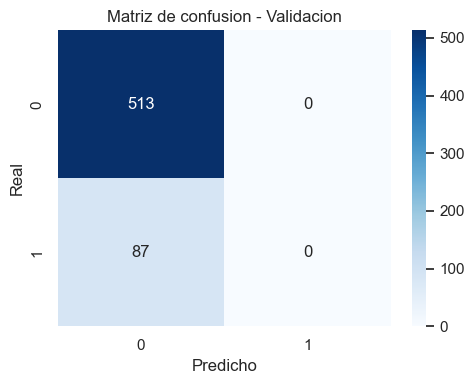

In [7]:
cm = confusion_matrix(y_val, pred_val)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusion - Validacion')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 6. Data Leakage: Error Comun

### Que es?
Data leakage ocurre cuando el modelo recibe informacion que, en la realidad, no estaria disponible al momento de predecir.

Ejemplo: variables creadas despues del evento (como una gestion de cancelacion posterior al abandono).

### Para que sirve detectarlo?
Porque puede generar metricas artificialmente altas y decisiones equivocadas en produccion.

El modelo "parece brillante" en pruebas, pero falla cuando se usa en el mundo real.

### Como se evita?
1. Entender el proceso temporal del negocio (que ocurre antes y despues)
2. Excluir columnas con informacion futura
3. Definir claramente momento de prediccion
4. Revisar variables sospechosas con stakeholders

En el bloque siguiente veremos una demostracion didactica de este problema.

In [8]:
# Ejemplo didactico: variable de fuga (no usar en produccion)
df_leak = df.copy()
df_leak['ticket_cancelacion'] = np.where(df_leak['abandono'] == 1, 1, np.random.binomial(1, 0.03, size=len(df_leak)))

X_leak = df_leak.drop(columns=['abandono'])
y_leak = df_leak['abandono']

Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_leak, y_leak, test_size=0.2, random_state=42, stratify=y_leak)

num_l = X_leak.select_dtypes(include=['number']).columns.tolist()
cat_l = X_leak.select_dtypes(exclude=['number']).columns.tolist()

pipe_leak = Pipeline(steps=[
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num_l),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_l)
    ])),
    ('clf', LogisticRegression(max_iter=1000))
])

pipe_leak.fit(Xl_train, yl_train)
pred_leak = pipe_leak.predict(Xl_test)

print('Accuracy con leakage: {:.3f}'.format(accuracy_score(yl_test, pred_leak)))
print('Nota: una metrica demasiado alta puede ocultar fuga de informacion.')

Accuracy con leakage: 0.970
Nota: una metrica demasiado alta puede ocultar fuga de informacion.


## 7. Evaluacion Final en Test

Usamos el conjunto de test solo una vez, al final, para estimar desempeno esperado en produccion.

In [9]:
pred_test = modelo.predict(X_test)
proba_test = modelo.predict_proba(X_test)[:, 1]

resultados_test = pd.Series({
    'accuracy_test': accuracy_score(y_test, pred_test),
    'precision_test': precision_score(y_test, pred_test, zero_division=0),
    'recall_test': recall_score(y_test, pred_test, zero_division=0),
    'f1_test': f1_score(y_test, pred_test, zero_division=0),
    'roc_auc_test': roc_auc_score(y_test, proba_test)
}).round(3)

resultados_test

accuracy_test     0.857
precision_test    0.000
recall_test       0.000
f1_test           0.000
roc_auc_test      0.613
dtype: float64

## 8. Ejercicio Practico Integrador

### Que es?
Una practica corta para consolidar el ciclo completo de modelado.

### Para que sirve?
Refuerza tres habilidades clave:
- crear features con sentido de negocio
- validar si aportan mejora real
- comunicar una conclusion comprensible para stakeholders

### Instrucciones
1. Crea una nueva feature: uso_por_antiguedad = uso_mensual_horas / antiguedad_meses
2. Reentrena el modelo
3. Compara F1 en validacion frente al modelo anterior
4. Escribe una conclusion de negocio en 3 lineas

Pista: no toda nueva variable mejora el modelo; lo importante es medir y justificar.

In [10]:
df_ej = df.copy()
df_ej['uso_por_antiguedad'] = df_ej['uso_mensual_horas'] / df_ej['antiguedad_meses'].replace(0, 1)

X_ej = df_ej.drop(columns=['abandono'])
y_ej = df_ej['abandono']

Xe_train, Xe_val, ye_train, ye_val = train_test_split(
    X_ej, y_ej, test_size=0.25, random_state=42, stratify=y_ej
)

num_e = X_ej.select_dtypes(include=['number']).columns.tolist()
cat_e = X_ej.select_dtypes(exclude=['number']).columns.tolist()

pipe_ej = Pipeline(steps=[
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num_e),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_e)
    ])),
    ('clf', LogisticRegression(max_iter=1000))
])

pipe_ej.fit(Xe_train, ye_train)
pred_ej = pipe_ej.predict(Xe_val)

print('F1 ejercicio: {:.3f}'.format(f1_score(ye_val, pred_ej, zero_division=0)))
print('Completa la conclusion de negocio en una celda markdown adicional.')

F1 ejercicio: 0.000
Completa la conclusion de negocio en una celda markdown adicional.


## Cierre

En este notebook aprendiste:
- Flujo base de modelado predictivo
- Importancia de baseline y splits correctos
- Riesgo de data leakage
- Evaluacion inicial para clasificacion

Siguiente paso recomendado: notebook 17 para comparar modelos de regresion y clasificacion en escenarios concretos.